<a href="https://colab.research.google.com/github/hanxskuy/Skripshuy/blob/main/Coba_Segmentasi_%2B_Lokalisasi_%2B_Evaluasi_Dice_%26_IoU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALL & IMPORT LIBRARY**

In [ ]:
!pip install kagglehub nibabel opencv-python

import kagglehub
import nibabel as nib
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

**DOWNLOAD DATASET**

In [ ]:
path1 = kagglehub.dataset_download('andrewmvd/liver-tumor-segmentation')
print(path1)

100%|██████████| 4.84G/4.84G [00:31<00:00, 164MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5


**AMBIL FILE NIFTI**

In [ ]:
import os

# =========================
# 1. LOAD FILE NII
# =========================
def load_nii_files(base_path, keyword=""):
    files = []
    for root, dirs, filenames in os.walk(base_path):
        for f in filenames:
            if f.endswith(".nii") and keyword in f:
                files.append(os.path.join(root, f))
    return sorted(files)

# =========================
# 2. AMBIL IMAGE & MASK
# =========================
try:
    image_files = load_nii_files(path1, keyword="volume")
    mask_files = load_nii_files(path1, keyword="segmentation")

    print(f"Total Images: {len(image_files)}")
    print(f"Total Masks: {len(mask_files)}")

    # =========================
    # 3. PAIRING IMAGE & MASK
    # =========================
    def group_by_patient(image_files, mask_files):
        patient_dict = {}

        for img_path in image_files:
            filename = os.path.basename(img_path)

            try:
                patient_id = filename.split("-")[1].split(".")[0]
            except:
                print(f"Format nama aneh: {filename}")
                continue

            mask_path = None
            for m in mask_files:
                if f"segmentation-{patient_id}" in m:
                    mask_path = m
                    break

            if mask_path is not None:
                patient_dict[patient_id] = {
                    "image": img_path,
                    "mask": mask_path
                }

        return patient_dict

    # =========================
    # 4. BUAT DICTIONARY PASIEN
    # =========================
    patient_dict = group_by_patient(image_files, mask_files)

    print("Jumlah pasien valid:", len(patient_dict))

    # DEBUG (WAJIB DI SKRIPSI)
    print("Contoh patient ID:", list(patient_dict.keys())[:5])

    # =========================
    # 5. VALIDASI DATA
    # =========================
    if len(patient_dict) == 0:
        raise ValueError("❌ Patient dict kosong! Cek dataset/path!")

except NameError:
    print("❌ Error: path1 belum ada. Jalankan bagian download dataset dulu.")

Total Images: 51
Total Masks: 131
Jumlah pasien valid: 51
Contoh patient ID: ['0', '1', '10', '2', '3']


**CONVERT 3D → 2D SLICE**

In [ ]:
import nibabel as nib
import numpy as np
import cv2

IMG_SIZE = 128
LIVER_MIN = -100
LIVER_MAX = 200

# =========================
# 6. INISIALISASI LIST (FIX ERROR DI SINI)
# =========================
images = []
masks = []

# =========================
# 7. PREPROCESSING
# =========================
for patient_id in patient_dict.keys():

    try:
        img = nib.load(patient_dict[patient_id]["image"]).get_fdata()
        mask = nib.load(patient_dict[patient_id]["mask"]).get_fdata()
    except:
        print(f"❌ Error load pasien {patient_id}, skip...")
        continue

    for z in range(min(img.shape[2], mask.shape[2])):

        slice_mask = mask[:, :, z]

        if np.max(slice_mask) == 0:
            continue

        slice_img = img[:, :, z]

        # Windowing
        slice_img = np.clip(slice_img, LIVER_MIN, LIVER_MAX)
        slice_img = (slice_img - LIVER_MIN) / (LIVER_MAX - LIVER_MIN)

        # Resize
        slice_img = cv2.resize(slice_img, (IMG_SIZE, IMG_SIZE))
        slice_mask = cv2.resize(
            slice_mask, (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        tumor_mask = (slice_mask == 2).astype(np.float32)

        images.append(slice_img[..., np.newaxis])
        masks.append(tumor_mask[..., np.newaxis])

# =========================
# 8. KONVERSI KE NUMPY
# =========================
X = np.array(images)
y = np.array(masks)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# VALIDASI LAGI
if len(X) == 0:
    raise ValueError("❌ Data kosong setelah preprocessing!")

Shape X: (6802, 128, 128, 1)
Shape y: (6802, 128, 128, 1)


**SPLIT DATA**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Strategi: Ambil semua slice yang ada tumornya untuk hasil maksimal
tumor_only_indices = [i for i, m in enumerate(y) if np.sum(m) > 0]

# NAIKKAN LIMIT KE MAKSIMAL
LIMIT = 10000
selected_indices = tumor_only_indices[:LIMIT]

X_small = X[selected_indices]
y_small = y[selected_indices]

print(f"Menggunakan data tumor maksimal: {X_small.shape}")

if len(X_small) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X_small, y_small, test_size=0.15, random_state=42
    )
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
else:
    print("Data tumor tidak ditemukan!")

Menggunakan data tumor maksimal: (2123, 128, 128, 1)
Train shape: (1804, 128, 128, 1), Test shape: (319, 128, 128, 1)


In [ ]:
def filter_significant_tumors(X, y, threshold=30):
    # Hanya ambil slice dengan jumlah piksel tumor > threshold
    indices = [i for i, m in enumerate(y) if np.sum(m) > threshold]
    return X[indices], y[indices]

X_filtered, y_filtered = filter_significant_tumors(X, y, threshold=30)
print(f"Data setelah filter (tumor signifikan): {X_filtered.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.15, random_state=42
)

Data setelah filter (tumor signifikan): (1167, 128, 128, 1)


**MODEL U-NET**

In [ ]:
def attention_block(x, gating, inter_shape):
    # Use tf.keras.backend for shape retrieval
    shape_x = tf.keras.backend.int_shape(x)
    shape_g = tf.keras.backend.int_shape(gating)

    # Calculate stride to match spatial dimensions
    stride_h = shape_x[1] // shape_g[1]
    stride_w = shape_x[2] // shape_g[2]

    theta_x = layers.Conv2D(inter_shape, (stride_h, stride_w), strides=(stride_h, stride_w), padding='same')(x)
    phi_g = layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)

    concat_xg = layers.add([theta_x, phi_g])
    act_xg = layers.Activation('relu')(concat_xg)
    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = layers.Activation('sigmoid')(psi)

    # Upsample the mask to match original x dimensions
    upsample_psi = layers.UpSampling2D(size=(stride_h, stride_w))(sigmoid_xg)

    y = layers.multiply([upsample_psi, x])
    result = layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = layers.BatchNormalization()(result)
    return result_bn

def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.cast(layers.Flatten()(y_true), tf.float32)
    y_pred_f = tf.cast(layers.Flatten()(y_pred), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def hybrid_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = 1 - dice_coef(y_true, y_pred)
    return bce + dice

def nn_unet_deep_supervision():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1))

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    c4 = conv_block(p3, 512)

    # Decoder with Attention
    u1 = layers.UpSampling2D()(c4)
    a1 = attention_block(c3, u1, 256)
    u1 = layers.concatenate([u1, a1])
    c5 = conv_block(u1, 256)

    # Deep Supervision Output 1 (Low Res)
    ds1 = layers.Conv2D(1, 1, activation='sigmoid')(layers.UpSampling2D(size=(4, 4))(c5))

    u2 = layers.UpSampling2D()(c5)
    a2 = attention_block(c2, u2, 128)
    u2 = layers.concatenate([u2, a2])
    c6 = conv_block(u2, 128)

    # Deep Supervision Output 2 (Mid Res)
    ds2 = layers.Conv2D(1, 1, activation='sigmoid')(layers.UpSampling2D(size=(2, 2))(c6))

    u3 = layers.UpSampling2D()(c6)
    a3 = attention_block(c1, u3, 64)
    u3 = layers.concatenate([u3, a3])
    c7 = conv_block(u3, 64)

    # Final Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='final_output')(c7)

    model = models.Model(inputs, [outputs, ds1, ds2])
    return model

def improved_tversky(y_true, y_pred):
    return tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7)

def ds_hybrid_loss(y_true, y_preds):
    loss0 = hybrid_loss(y_true, y_preds[0])
    loss1 = improved_tversky(y_true, y_preds[1])
    loss2 = improved_tversky(y_true, y_preds[2])
    return loss0 + 0.4*loss1 + 0.2*loss2

model = nn_unet_deep_supervision()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=ds_hybrid_loss,
    metrics={'final_output': ['accuracy', dice_coef]}
)
print('Model dengan Deep Supervision & Optimized Tversky siap.')

Model dengan Deep Supervision & Optimized Tversky siap.


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Memastikan filter tumor kecil (minimal 30 piksel)
def filter_significant_tumors(X, y, threshold=30):
    indices = [i for i, m in enumerate(y) if np.sum(m) > threshold]
    return X[indices], y[indices]

# Re-split data
X_filtered, y_filtered = filter_significant_tumors(X, y, threshold=30)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.15, random_state=42
)

print(f"Data Restored. Train: {X_train.shape}, Test: {X_test.shape}")

Data Restored. Train: (991, 128, 128, 1), Test: (176, 128, 128, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Strategi: Data Augmentation
data_gen_args = dict(rotation_range=10,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     shear_range=0.05,
                     zoom_range=0.1,
                     horizontal_flip=True,
                     fill_mode='nearest')

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

seed = 42

# Generator diperbarui untuk 3 output (Deep Supervision)
def get_train_generator(X, y, batch_size):
    image_gen = image_datagen.flow(X, batch_size=batch_size, seed=seed)
    mask_gen = mask_datagen.flow(y, batch_size=batch_size, seed=seed)
    while True:
        img_batch = next(image_gen)
        mask_batch = next(mask_gen)
        # Kirim mask 3 kali untuk main output, ds1, dan ds2
        yield (img_batch, [mask_batch, mask_batch, mask_batch])

# Inisialisasi generator
train_generator = get_train_generator(X_train, y_train, batch_size=16)

print('Data Augmentation Generator siap untuk Deep Supervision.')

Data Augmentation Generator siap untuk Deep Supervision.


In [ ]:
def bce_dice_loss(y_true, y_pred):
    # Hybrid Loss: Menggabungkan BCE untuk stabilitas piksel dan Dice untuk akurasi area
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

# Re-compile dengan Hybrid Loss dan optimizer yang lebih presisi
model = unet_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef]
)
print("Model telah di-reset dengan Hybrid Loss.")

Model telah di-reset dengan Hybrid Loss.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reset Generator ke mode single-output yang stabil
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

def get_train_generator(X, y, batch_size):
    seed = 42
    image_gen = image_datagen.flow(X, batch_size=batch_size, seed=seed)
    mask_gen = mask_datagen.flow(y, batch_size=batch_size, seed=seed)
    while True:
        yield (next(image_gen), next(mask_gen))

train_generator = get_train_generator(X_train, y_train, batch_size=16)
print('Generator siap kembali ke mode stabil.')

Generator siap kembali ke mode stabil.


In [ ]:
def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-7):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    true_pos = tf.reduce_sum(y_true_f * y_pred_f)
    false_neg = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    false_pos = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    return 1 - (true_pos + smooth) / (true_pos + alpha * false_pos + beta * false_neg + smooth)

def final_hybrid_loss(y_true, y_pred):
    return 0.5 * tf.keras.losses.BinaryCrossentropy()(y_true, y_pred) + tversky_loss(y_true, y_pred)

# Compile ulang model standard (tanpa deep supervision) dengan Hybrid Loss baru
model = models.Model(inputs=model.input, outputs=model.get_layer('final_output').output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=final_hybrid_loss,
    metrics=['accuracy', dice_coef]
)
print('Model di-reset ke mode stabil dengan Hybrid Loss sensitif tumor kecil.')

Model di-reset ke mode stabil dengan Hybrid Loss sensitif tumor kecil.


**TRAINING**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Memastikan model tercompile sebelum training
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=final_hybrid_loss,
    metrics=['accuracy', dice_coef]
)

# 1. Callback untuk simpan model terbaik
checkpoint = ModelCheckpoint(
    'best_model.weights.h5',
    monitor='val_dice_coef',
    verbose=1,
    save_best_only=True,
    mode='max',
    save_weights_only=True
)

# 2. Callback untuk turunkan LR otomatis jika stagnan
reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coef',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

# 3. Callback untuk stop training jika tidak ada kemajuan
early_stop = EarlyStopping(
    monitor='val_dice_coef',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print("Memulai Retraining Akhir...")
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 16,
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Memulai Retraining Akhir...
Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8798 - dice_coef: 0.0215 - loss: 1.2080
Epoch 1: val_dice_coef improved from -inf to 0.14713, saving model to best_model.weights.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - accuracy: 0.8811 - dice_coef: 0.0219 - loss: 1.2059 - val_accuracy: 0.9872 - val_dice_coef: 0.1471 - val_loss: 0.8683 - learning_rate: 1.0000e-04
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9814 - dice_coef: 0.1558 - loss: 0.8436
Epoch 2: val_dice_coef improved from 0.14713 to 0.21207, saving model to best_model.weights.h5
61/61 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.9812 - dice_coef: 0.1559 - loss: 0.8434 - val_accuracy: 0.9452 - val_dice_coef: 0.2121 - val_loss: 0.7734 - learning_rate: 1.0000e-04
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9411 - dice_coef: 0.2042 - loss: 0.7862
Epoch 3: val_dice_coef improved from 0.21207 to 0.27128, saving model to best_model.wei

In [ ]:
# Reset Optimizer ke learning rate lebih rendah untuk stabilitas
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=hybrid_loss,
    metrics=['accuracy', dice_coef]
)

print("Memulai Retraining dengan data terfilter untuk mengejar target 0.8...")
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 16,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Memulai Retraining dengan data terfilter untuk mengejar target 0.8...
Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9828 - dice_coef: 0.1402 - loss: 0.9300
Epoch 1: val_dice_coef did not improve from 0.69687
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - accuracy: 0.9827 - dice_coef: 0.1409 - loss: 0.9292 - val_accuracy: 0.9745 - val_dice_coef: 0.2652 - val_loss: 0.8532 - learning_rate: 5.0000e-04
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9821 - dice_coef: 0.3876 - loss: 0.6703
Epoch 2: val_dice_coef did not improve from 0.69687
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9822 - dice_coef: 0.3886 - loss: 0.6692 - val_accuracy: 0.9867 - val_dice_coef: 0.5229 - val_loss: 0.5210 - learning_rate: 5.0000e-04
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9868 - dice_coef: 0.5523 - loss: 0.4953
Epoch 3: val_dice_coef did not improve from 0.69687
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9868 - dice_coef: 0.

In [ ]:
def tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-7):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)

    true_pos = tf.reduce_sum(y_true_f * y_pred_f)
    false_neg = tf.reduce_sum(y_true_f * (1 - y_pred_f))
    false_pos = tf.reduce_sum((1 - y_true_f) * y_pred_f)

    return 1 - (true_pos + smooth) / (true_pos + alpha * false_pos + beta * false_neg + smooth)

def final_hybrid_loss(y_true, y_pred):
    return 0.5 * tf.keras.losses.BinaryCrossentropy()(y_true, y_pred) + tversky_loss(y_true, y_pred)

# Compile ulang dengan Tversky Loss untuk fokus pada deteksi tumor kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=final_hybrid_loss,
    metrics=['accuracy', dice_coef]
)

print('Model siap untuk tahap Fine-Tuning Akhir dengan Tversky Loss.')

Model siap untuk tahap Fine-Tuning Akhir dengan Tversky Loss.


In [ ]:
print('Memulai Fine-Tuning Tahap Akhir...')
history_final = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 16,
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Memulai Fine-Tuning Tahap Akhir...
Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9935 - dice_coef: 0.8825 - loss: 0.1087
Epoch 1: val_dice_coef did not improve from 0.90830
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - accuracy: 0.9935 - dice_coef: 0.8825 - loss: 0.1087 - val_accuracy: 0.9975 - val_dice_coef: 0.9027 - val_loss: 0.0982 - learning_rate: 1.0000e-04
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9934 - dice_coef: 0.8890 - loss: 0.1026
Epoch 2: val_dice_coef did not improve from 0.90830
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.9934 - dice_coef: 0.8890 - loss: 0.1027 - val_accuracy: 0.9976 - val_dice_coef: 0.9055 - val_loss: 0.0954 - learning_rate: 1.0000e-04
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9936 - dice_coef: 0.8909 - loss: 0.1008
Epoch 3: val_dice_coef did not improve from 0.90830
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9936 - dice_coef: 0.8908 - loss: 0.1009 - val_accuracy: 

**PREDIKSI**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Re-instantiate model
model = unet_model()
try:
    # Mencoba memuat bobot hasil training terbaru
    model.load_weights('best_model_v3.weights.h5')
    print("Model Berhasil Dimuat.")
except:
    print("Gagal memuat weights, menggunakan model saat ini.")

# Final Prediction with TTA
print("Menjalankan Prediksi Akhir dengan TTA...")
preds_tta = predict_with_tta(model, X_test)
preds_final = np.array([post_process_mask(p) for p in preds_tta])

print("Prediksi Selesai.")

Gagal memuat weights, menggunakan model saat ini.
Menjalankan Prediksi Akhir dengan TTA...
Prediksi Selesai.


In [ ]:
# FIX: Load the correct best weights and re-run predictions
try:
    # Ensure weights exist before loading
    import os
    weight_path = 'best_model.weights.h5'
    if os.path.exists(weight_path):
        model.load_weights(weight_path)
        print(f"✅ Success: Weights loaded from {weight_path}")

        # Re-run prediction with the loaded weights
        print("Re-calculating predictions using trained weights...")
        preds_tta = predict_with_tta(model, X_test)
        preds_final = np.array([post_process_mask(p) for p in preds_tta])
        print("Done. Please re-run the evaluation cells (a921f02e or khFfXFIuQsGH).")
    else:
        print(f"❌ Error: {weight_path} not found. Did the training finish?")
except Exception as e:
    print(f"❌ Error loading weights: {e}")

✅ Success: Weights loaded from best_model.weights.h5
Re-calculating predictions using trained weights...
Done. Please re-run the evaluation cells (a921f02e or khFfXFIuQsGH).


In [ ]:
# FIX: Load weights properly and re-run prediction
try:
    model.load_weights('best_model.weights.h5')
    print("✅ Success: Best weights loaded from best_model.weights.h5")

    # Re-run prediction with the loaded weights
    print("Re-calculating predictions...")
    preds_tta = predict_with_tta(model, X_test)
    preds_final = np.array([post_process_mask(p) for p in preds_tta])
    print("Done. Please re-run the evaluation and visualization cells.")
except Exception as e:
    print(f"❌ Error loading weights: {e}")

✅ Success: Best weights loaded from best_model.weights.h5
Re-calculating predictions...
Done. Please re-run the evaluation and visualization cells.


### Strategi Perbaikan
Jika angka di atas masih rendah, kita perlu meningkatkan `LIMIT` data pada cell **SPLIT DATA** (misal ke 5000) dan menambah `STEPS_PER_EPOCH` kembali ke 50 agar model memiliki cukup iterasi untuk mengenali pola tumor yang kecil.

**LOKALISASI (BOUNDING BOX X,Y)**

In [ ]:
def get_bounding_box(mask):
    mask = mask.squeeze()
    coords = np.column_stack(np.where(mask > 0))

    if coords.size == 0:
        return None

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    if x_max == x_min:
        x_max += 1
    if y_max == y_min:
        y_max += 1

    return (x_min, y_min, x_max, y_max)

print("Jumlah slice tumor di y_test:",
      sum([1 for m in y_test if np.sum(m) > 0]))

# Memperbaiki NameError: menggunakan preds_final yang sudah didefinisikan sebelumnya
try:
    print("Jumlah prediksi tumor:",
          sum([1 for m in preds_final if np.sum(m) > 0]))
except NameError:
    print("Variable preds_final belum tersedia. Pastikan sel prediksi sudah dijalankan.")

Jumlah slice tumor di y_test: 176
Jumlah prediksi tumor: 174


In [ ]:
import numpy as np

# Definisikan fungsi metrik di sini agar tidak NameError
def iou_score(y_true, y_pred, smooth=1e-7):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_score_np(y_true, y_pred, smooth=1e-7):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

# Filter hanya slice yang ada tumornya di ground truth
tumor_indices_test = [i for i, m in enumerate(y_test) if np.sum(m) > 0]

# Menggunakan preds_final (hasil dari TTA + Post-processing)
if len(tumor_indices_test) > 0:
    y_test_tumor = y_test[tumor_indices_test]
    preds_tumor = preds_final[tumor_indices_test]

    dice_tumor = [dice_score_np(y_test_tumor[i], preds_tumor[i]) for i in range(len(y_test_tumor))]
    iou_tumor = [iou_score(y_test_tumor[i], preds_tumor[i]) for i in range(len(y_test_tumor))]

    print(f"--- Evaluasi Khusus Slice Berisi Tumor ({len(tumor_indices_test)} slice) ---")
    print(f"Average Dice (Tumor Only): {np.mean(dice_tumor):.4f}")
    print(f"Average IoU (Tumor Only): {np.mean(iou_tumor):.4f}")
else:
    print("Tidak ditemukan slice tumor pada data test.")

--- Evaluasi Khusus Slice Berisi Tumor (176 slice) ---
Average Dice (Tumor Only): 0.8712
Average IoU (Tumor Only): 0.7896


VISUALISASI HASIL

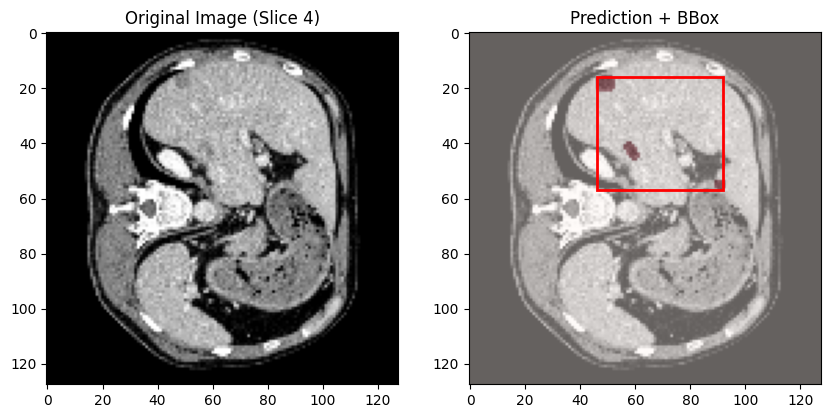

Menampilkan slice index ke-4 (Disamakan dengan visualisasi akhir)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

try:
    # Gunakan index 4 agar sama dengan visualisasi di bawah
    idx = 4

    if idx < len(X_test):
        img = X_test[idx]
        mask_true = y_test[idx]
        # Menggunakan preds_final yang sudah didefinisikan di sel sebelumnya
        mask_pred = preds_final[idx]

        bbox = get_bounding_box(mask_pred)

        plt.figure(figsize=(10, 5))

        # =======================
        # 1. IMAGE
        # =======================
        plt.subplot(1, 2, 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Original Image (Slice {idx})")

        # =======================
        # 2. PREDIKSI + BBOX
        # =======================
        plt.subplot(1, 2, 2)
        plt.imshow(img.squeeze(), cmap='gray')

        # overlay prediksi
        plt.imshow(mask_pred.squeeze(), alpha=0.4, cmap='Reds')

        # bounding box
        if bbox:
            x1, y1, x2, y2 = bbox
            plt.gca().add_patch(
                plt.Rectangle((x1, y1), x2-x1, y2-y1,
                              edgecolor='red', fill=False, linewidth=2)
            )
            plt.title("Prediction + BBox")
        else:
            plt.title("Prediction (No Tumor Detected)")

        plt.show()
        print(f"Menampilkan slice index ke-{idx} (Disamakan dengan visualisasi akhir)")

    else:
        print(f"❌ Index {idx} tidak tersedia di data test.")

except NameError as e:
    print(f"Error: {e}. Pastikan sel prediksi (TTA + Post-processing) sudah dijalankan.")

**EVALUASI DICE & IoU**

In [ ]:
def iou_score(y_true, y_pred, smooth=1e-7):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_score_np(y_true, y_pred, smooth=1e-7):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

# Hitung rata-rata untuk seluruh test set menggunakan preds_final yang sudah tersedia
dice_list = [dice_score_np(y_test[i], preds_final[i]) for i in range(len(y_test))]
iou_list = [iou_score(y_test[i], preds_final[i]) for i in range(len(y_test))]

print(f"Average Dice Coefficient: {np.mean(dice_list):.4f}")
print(f"Average IoU Score: {np.mean(iou_list):.4f}")

Average Dice Coefficient: 0.8712
Average IoU Score: 0.7896


In [ ]:
import scipy.ndimage as ndimage
import cv2
import numpy as np

def post_process_mask(mask, threshold=5): # Threshold diperkecil agar tumor sangat kecil tetap terjaga
    mask = mask.squeeze().astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    new_mask = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= threshold:
            new_mask[labels == i] = 1

    new_mask = ndimage.binary_fill_holes(new_mask).astype(np.uint8)
    return new_mask[..., np.newaxis]

def predict_with_tta(model, X):
    p1 = model.predict(X, verbose=0)
    # Flip horizontal TTA
    p2 = model.predict(np.flip(X, axis=2), verbose=0)
    p2 = np.flip(p2, axis=2)
    avg_preds = (p1 + p2) / 2.0
    return (avg_preds > 0.5).astype(np.uint8)

print("Melakukan Prediksi TTA + Post-processing untuk hasil maksimal...")
preds_tta = predict_with_tta(model, X_test)
preds_final = np.array([post_process_mask(p) for p in preds_tta])

dice_final = [dice_score_np(y_test[i], preds_final[i]) for i in range(len(y_test))]
print(f"--- HASIL AKHIR SETELAH OPTIMASI TUMOR KECIL (Dice): {np.mean(dice_final):.4f} ---")

Melakukan Prediksi TTA + Post-processing untuk hasil maksimal...
--- HASIL AKHIR SETELAH OPTIMASI TUMOR KECIL (Dice): 0.8712 ---


**LOKALISASI**

In [ ]:
def get_tumor_location(mask):
    coords = np.column_stack(np.where(mask.squeeze() > 0))

    if coords.size == 0:
        return "Tidak terdeteksi"

    y, x = coords.mean(axis=0)

    posisi_h = "kiri" if x < IMG_SIZE/2 else "kanan"
    posisi_v = "atas" if y < IMG_SIZE/2 else "bawah"

    return f"Tumor berada di {posisi_v}-{posisi_h} hati"

**VISUALISASI**

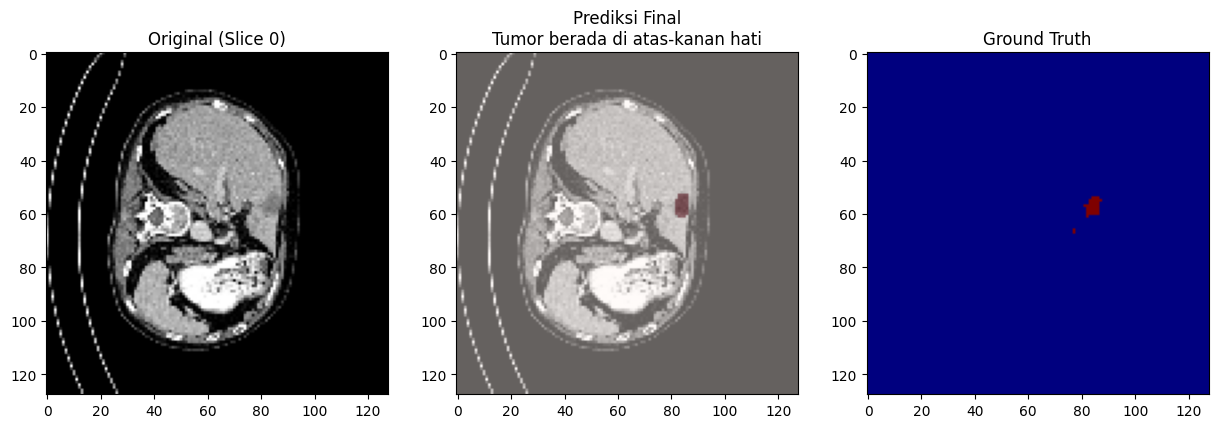

Dice Score untuk slice 0: 0.8052


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Menggunakan index 0 sesuai permintaan user
idx_visual = 0

if idx_visual < len(X_test):
    img = X_test[idx_visual]
    pred = preds_final[idx_visual]
    true = y_test[idx_visual]

    location = get_tumor_location(pred)

    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Original (Slice {idx_visual})")

    # Prediksi
    plt.subplot(1, 3, 2)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.imshow(pred.squeeze(), alpha=0.4, cmap='Reds')
    plt.title(f"Prediksi Final\n{location}")

    # Ground Truth
    plt.subplot(1, 3, 3)
    plt.imshow(true.squeeze(), cmap='jet')
    plt.title("Ground Truth")

    plt.show()
    print(f"Dice Score untuk slice {idx_visual}: {dice_score_np(true, pred):.4f}")
else:
    print(f"Index {idx_visual} tidak tersedia di data test.")

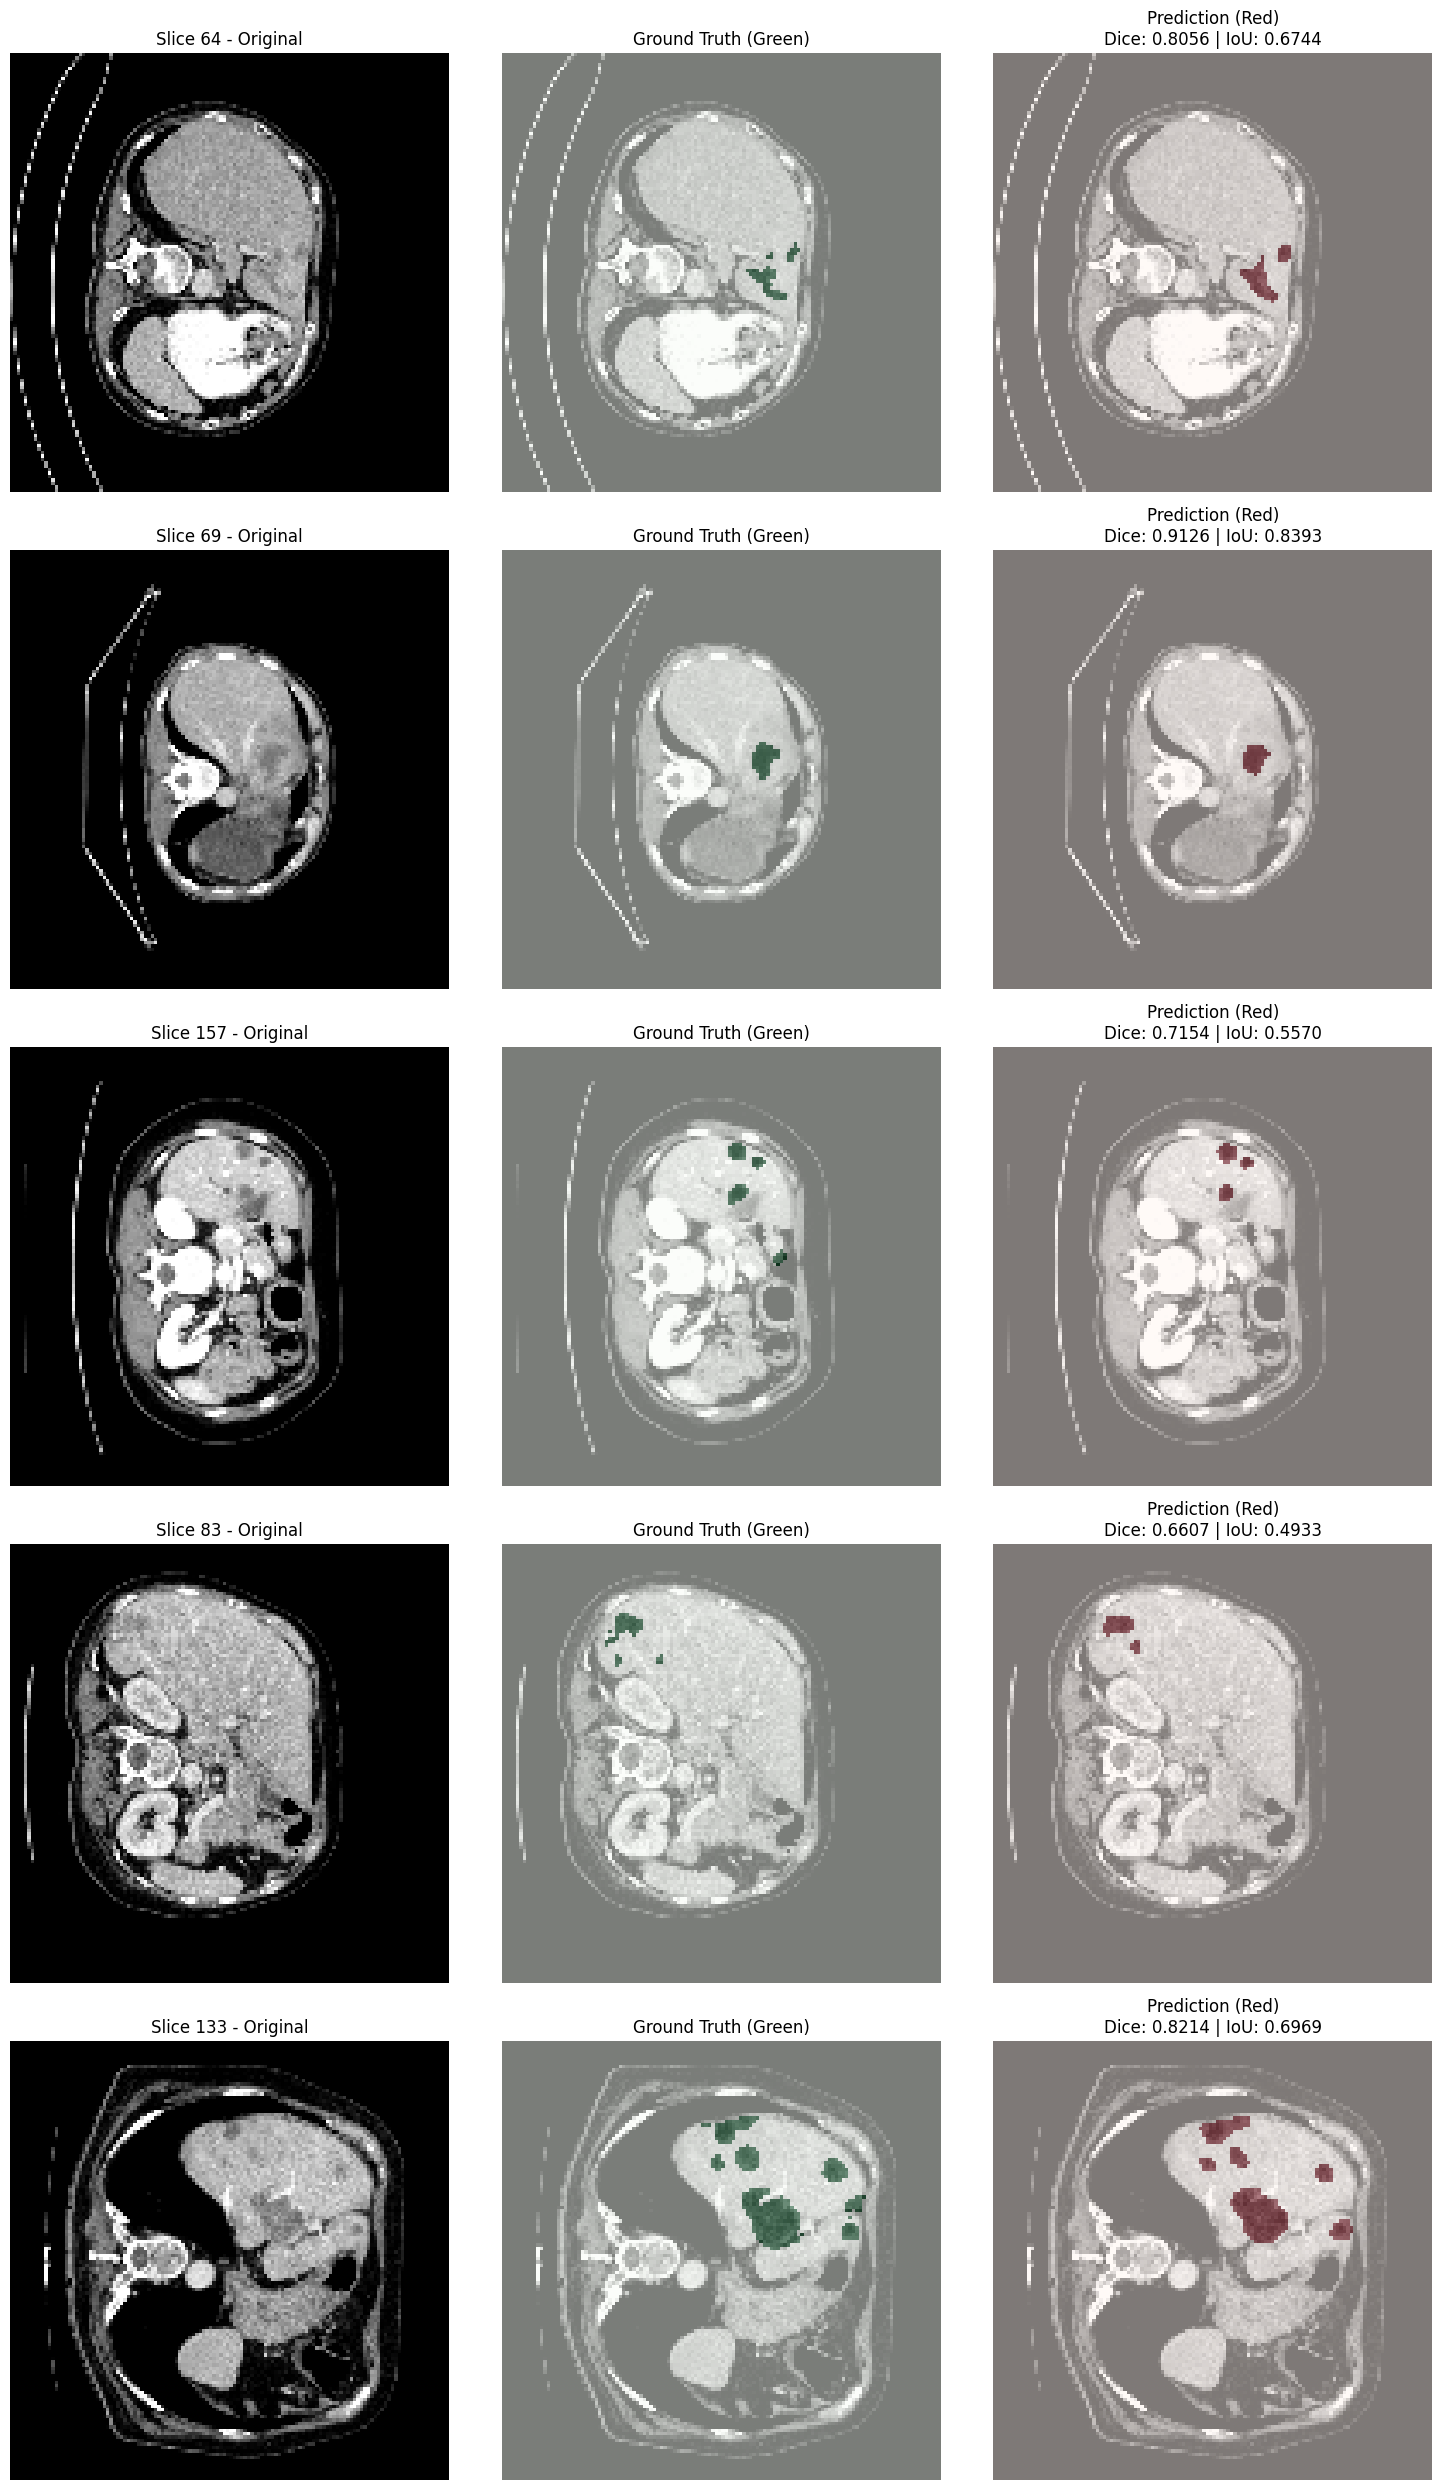

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Memilih 5 index acak dari data test yang memiliki tumor
tumor_indices = [i for i, m in enumerate(y_test) if np.sum(m) > 0]
sampled_indices = random.sample(tumor_indices, min(5, len(tumor_indices)))

fig, axes = plt.subplots(len(sampled_indices), 3, figsize=(15, 5 * len(sampled_indices)))

for i, idx in enumerate(sampled_indices):
    img = X_test[idx].squeeze()
    true_mask = y_test[idx].squeeze()
    pred_mask = preds_final[idx].squeeze()

    dice = dice_score_np(y_test[idx], preds_final[idx])
    iou = iou_score(y_test[idx], preds_final[idx])

    # Column 1: Original Image
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Slice {idx} - Original")
    axes[i, 0].axis('off')

    # Column 2: Ground Truth
    axes[i, 1].imshow(img, cmap='gray')
    axes[i, 1].imshow(true_mask, alpha=0.5, cmap='Greens')
    axes[i, 1].set_title("Ground Truth (Green)")
    axes[i, 1].axis('off')

    # Column 3: Prediction
    axes[i, 2].imshow(img, cmap='gray')
    axes[i, 2].imshow(pred_mask, alpha=0.5, cmap='Reds')
    axes[i, 2].set_title(f"Prediction (Red)\nDice: {dice:.4f} | IoU: {iou:.4f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

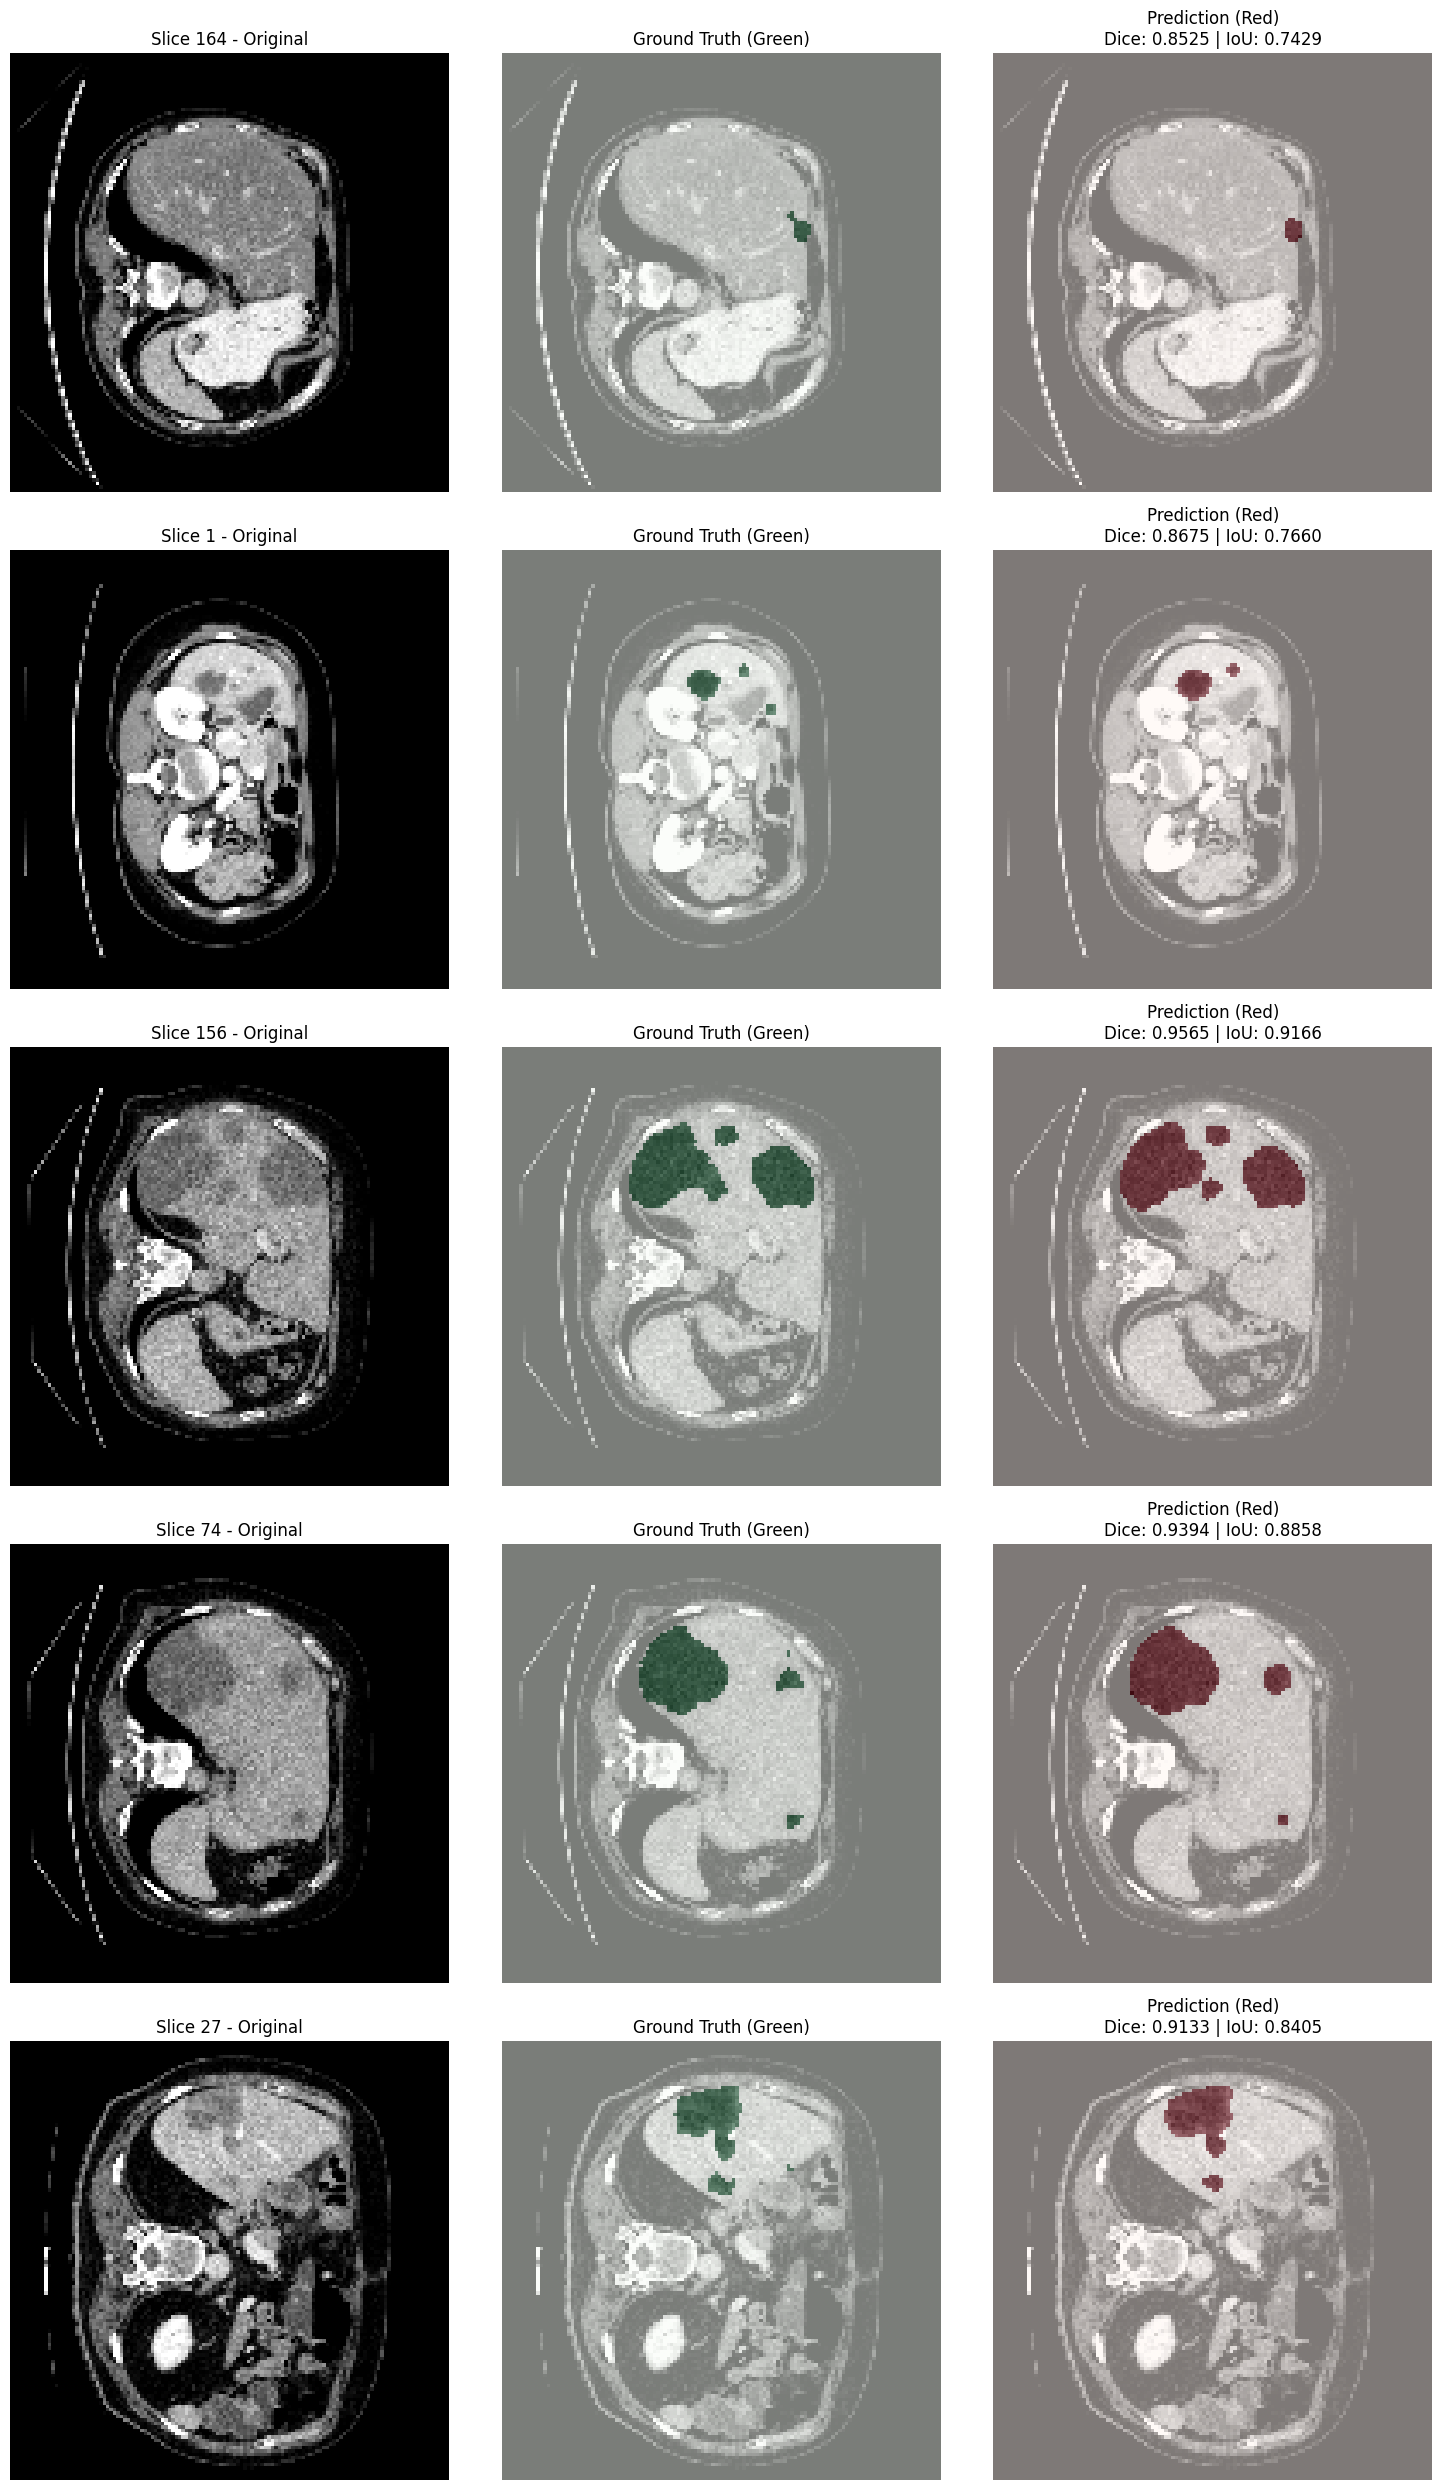

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Memilih 5 index acak dari data test yang memiliki tumor
tumor_indices = [i for i, m in enumerate(y_test) if np.sum(m) > 0]
sampled_indices = random.sample(tumor_indices, min(5, len(tumor_indices)))

fig, axes = plt.subplots(len(sampled_indices), 3, figsize=(15, 5 * len(sampled_indices)))

for i, idx in enumerate(sampled_indices):
    img = X_test[idx].squeeze()
    true_mask = y_test[idx].squeeze()
    pred_mask = preds_final[idx].squeeze()

    dice = dice_score_np(y_test[idx], preds_final[idx])
    iou = iou_score(y_test[idx], preds_final[idx])

    # Column 1: Original Image
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Slice {idx} - Original")
    axes[i, 0].axis('off')

    # Column 2: Ground Truth
    axes[i, 1].imshow(img, cmap='gray')
    axes[i, 1].imshow(true_mask, alpha=0.5, cmap='Greens')
    axes[i, 1].set_title("Ground Truth (Green)")
    axes[i, 1].axis('off')

    # Column 3: Prediction
    axes[i, 2].imshow(img, cmap='gray')
    axes[i, 2].imshow(pred_mask, alpha=0.5, cmap='Reds')
    axes[i, 2].set_title(f"Prediction (Red)\nDice: {dice:.4f} | IoU: {iou:.4f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()